In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("day.csv")

print("Dataset loaded successfully!")
print("Initial shape:", df.shape)
df.head()

Dataset loaded successfully!
Initial shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']

df = df.drop(columns=cols_to_drop, errors='ignore')

print("Columns removed successfully!")
print("Shape after dropping columns:", df.shape)
df.head()

Columns removed successfully!
Shape after dropping columns: (731, 11)


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


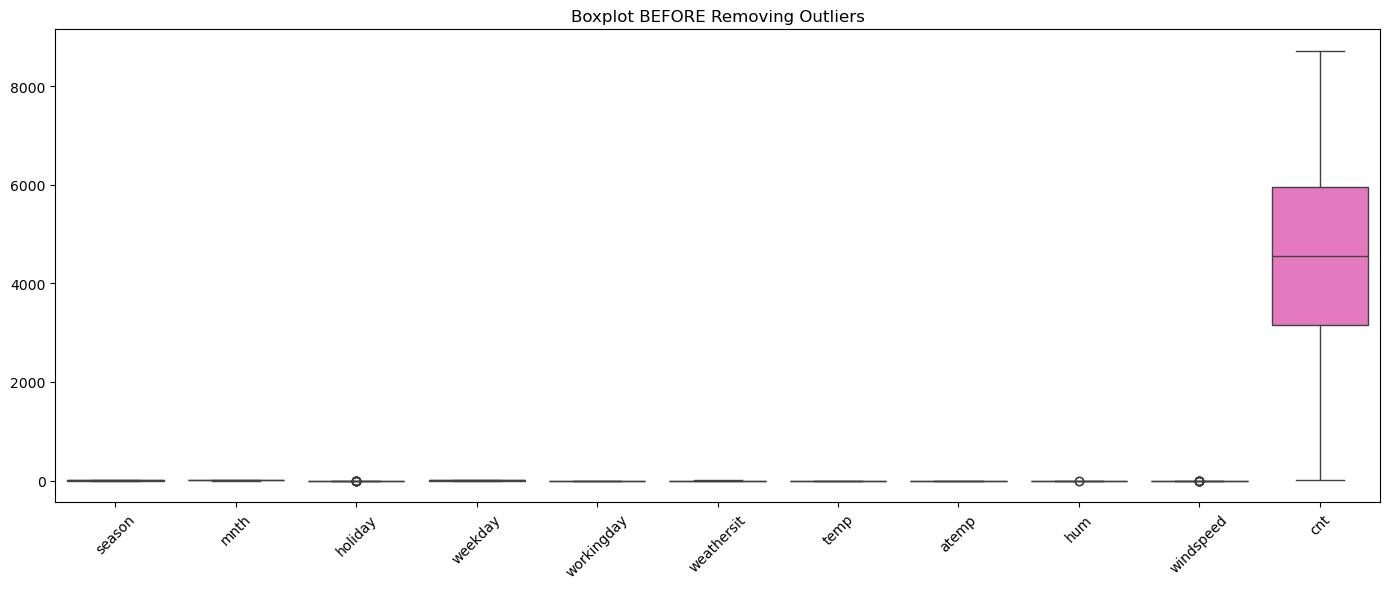

In [4]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Boxplot BEFORE Removing Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
outlier_counts = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_counts[col] = count

print("\nOutliers detected in each numeric column:")
print(pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count']))


Outliers detected in each numeric column:
            Outlier Count
season                  0
mnth                    0
holiday                21
weekday                 0
workingday              0
weathersit              0
temp                    0
atemp                   0
hum                     2
windspeed              13
cnt                     0


In [6]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include=np.number).columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("\nOutliers removed successfully!")
print("New dataset shape:", df_clean.shape)


Outliers removed successfully!
New dataset shape: (696, 11)


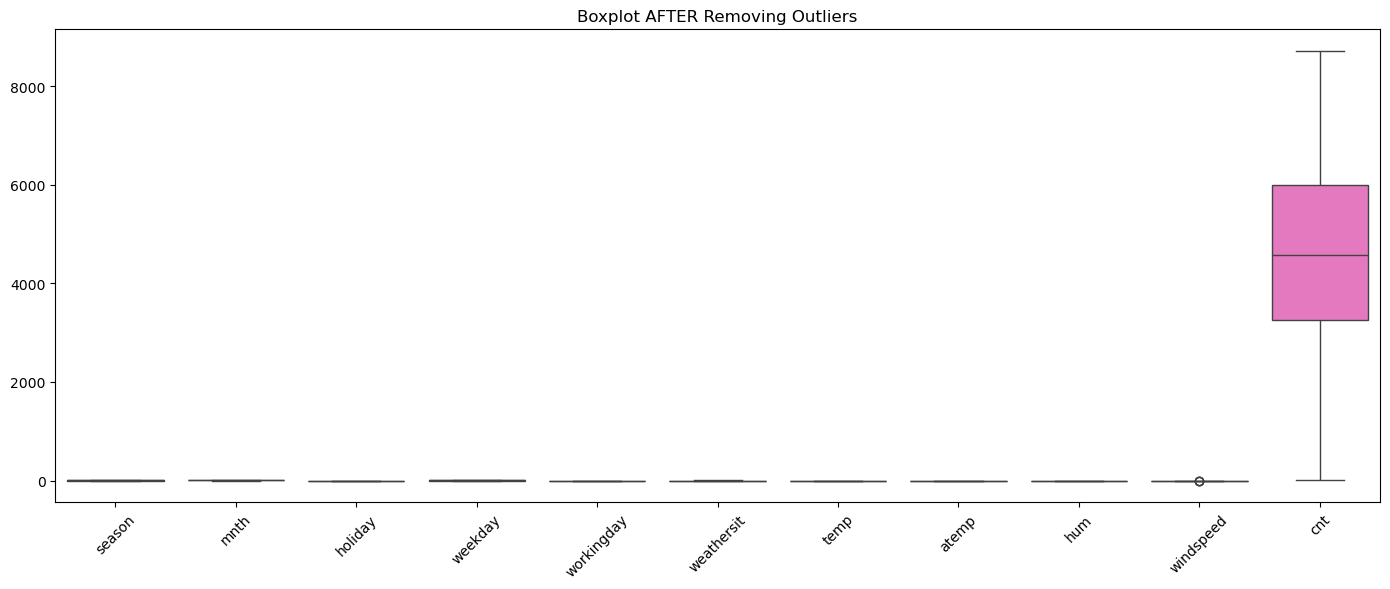

In [7]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean.select_dtypes(include='number'))
plt.title("Boxplot AFTER Removing Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
dfh = pd.read_csv("hour.csv")

print("Dataset loaded successfully!")
print("Initial shape:", dfh.shape)
dfh.head()

Dataset loaded successfully!
Initial shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']

dfh = dfh.drop(columns=cols_to_drop, errors='ignore')

print("Columns removed successfully!")
print("Shape after dropping columns:", dfh.shape)
dfh.head()

Columns removed successfully!
Shape after dropping columns: (17379, 12)


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


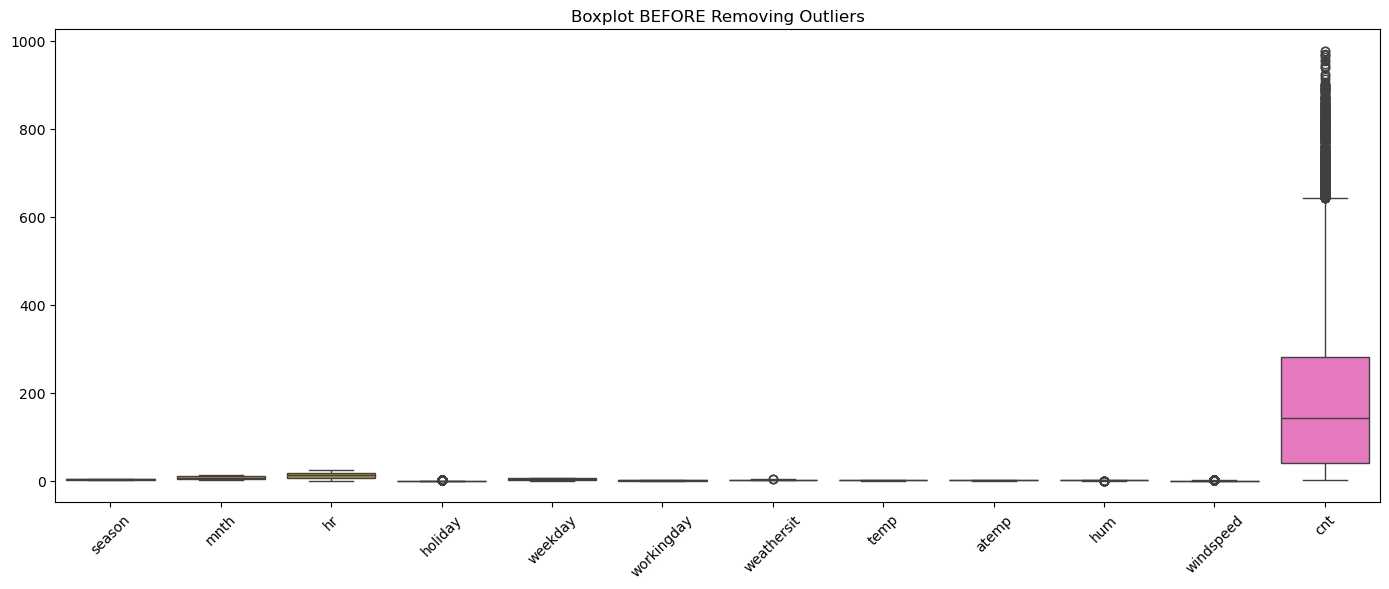

In [11]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=dfh.select_dtypes(include='number'))
plt.title("Boxplot BEFORE Removing Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
outlier_counts = {}

for col in dfh.select_dtypes(include=np.number).columns:
    Q1 = dfh[col].quantile(0.25)
    Q3 = dfh[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = dfh[(dfh[col] < lower) | (dfh[col] > upper)][col].count()
    outlier_counts[col] = count

print("\nOutliers detected in each numeric column:")
print(pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count']))


Outliers detected in each numeric column:
            Outlier Count
season                  0
mnth                    0
hr                      0
holiday               500
weekday                 0
workingday              0
weathersit              3
temp                    0
atemp                   0
hum                    22
windspeed             342
cnt                   505


In [13]:
dfh_clean = dfh.copy()

for col in dfh_clean.select_dtypes(include=np.number).columns:
    Q1 = dfh_clean[col].quantile(0.25)
    Q3 = dfh_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfh_clean = dfh_clean[(dfh_clean[col] >= lower) & (dfh_clean[col] <= upper)]

print("\nOutliers removed successfully!")
print("New dataset shape:", dfh_clean.shape)


Outliers removed successfully!
New dataset shape: (16042, 12)


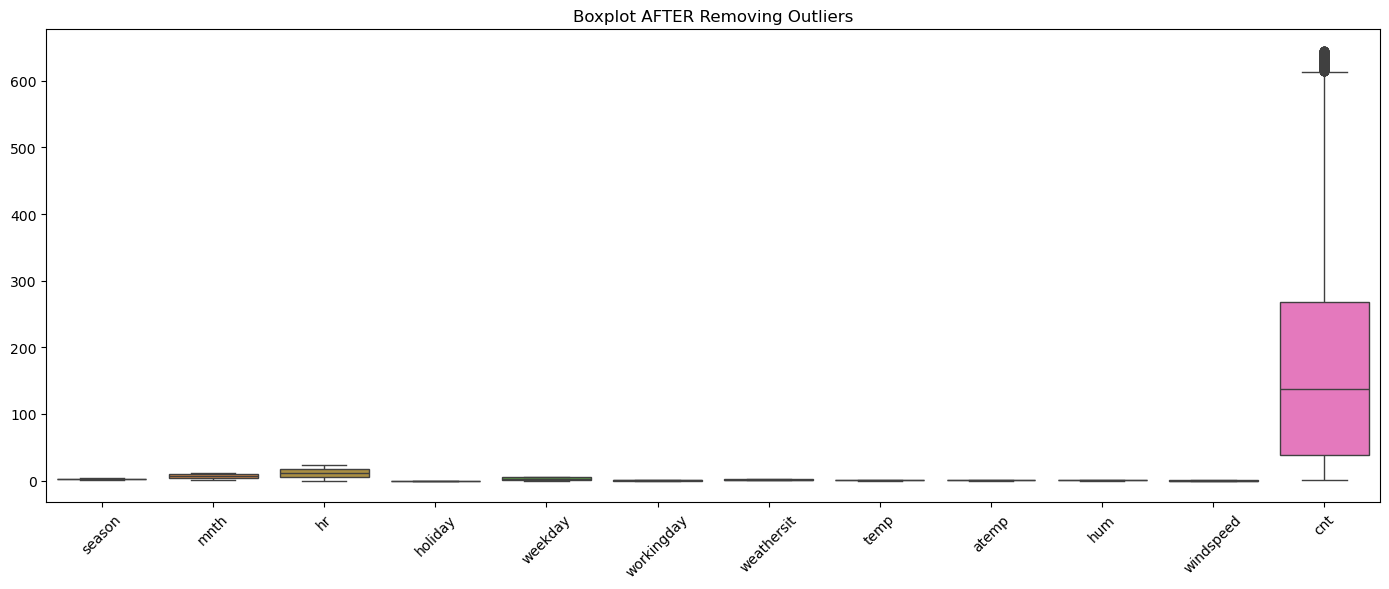

In [14]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=dfh_clean.select_dtypes(include='number'))
plt.title("Boxplot AFTER Removing Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()